Matplotlib is building the font cache; this may take a moment.


cluster
 0    101992
-1        11
Name: count, dtype: int64


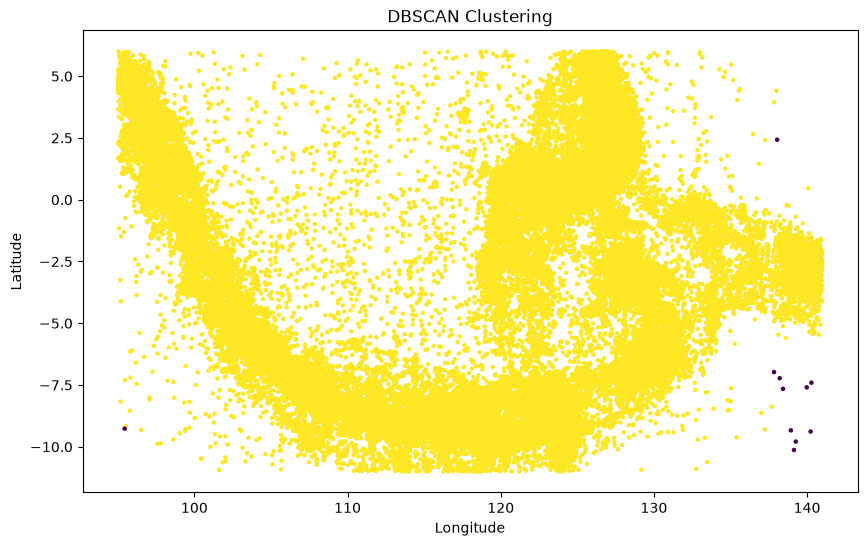

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# membuka preprocessed dataset
df = pd.read_csv("../outputs/preprocessed.csv")

#fitur spatial
X = df[["latitude", "longitude"]]

#standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#DBSCAN clustering
dbscan = DBSCAN(eps=0.3, min_samples=15)

df["cluster"] = dbscan.fit_predict(X_scaled)

#simpan hasil clustering
df.to_csv("../outputs/clustered.csv", index=False)

print(df["cluster"].value_counts())

#visualisasi hasil clustering
plt.figure(figsize=(10, 6))
plt.scatter(df["longitude"], df["latitude"], c=df["cluster"], s=5 )
plt.title("DBSCAN Clustering")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
